# Chapter 03-01 · Summaries: the arithmetic behind "typical" and "spread"

**Label:** Core  |  **Time:** ~45 minutes  |  **Difficulty:** gentle - every calculation here can be
done on paper, and you will do several

**Prerequisites:** 02-05, where you met means, medians and skew by eye. This chapter does the
arithmetic underneath them.

**Position in the learning path:** module 03, chapter 1 of 8 - the first mathematics chapter. After:
**03-02**, on why two samples of the same thing never agree.

---

## Why this matters

Module 02 used means and medians constantly and never defined them. That was deliberate: you needed
the judgement before the algebra. Now the algebra, because three things you cannot see from outside
turn out to matter.

- **The mean and the median are both answers to "what single number best represents this data".**
  They differ because "best" is defined differently, and you will meet that same fork again as the
  choice between two error metrics in module 07 and two loss functions in 03-08.
- **numpy and pandas compute different variances for the same numbers.** Not a bug; a convention, and
  the difference is 17% on the data below.
- **A quartile is a convention, not a fact.** numpy offers thirteen definitions and on seven numbers
  they disagree by 20%.

This chapter is Level 1 mathematics: counting, adding, dividing, and one square root. No derivations.

## What you will be able to do

- Compute mean, median, quantiles, variance and standard deviation by hand and say what each means
- Explain why the mean minimises one kind of error and the median another
- Say what `ddof` is and why the default differs between two libraries you use daily
- Quantify how far one bad value moves each summary
- Choose between mean and median for a stated purpose, and defend it

## Warm-up: retrieve, do not reread

1. In 02-05, why did the mean rise so far above the median on festival days?
2. What is the unit of an average of averages, and when is it wrong to take one?
3. Name one thing a bar chart of two means cannot show.

<br>

*Answers: (1) a few very large values pull the mean and leave the median where it is - the mean is a
statement about the total. (2) it has the same unit, but it is wrong whenever the groups have
different sizes, because it weights a small group as heavily as a large one. (3) the spread, and
therefore whether individuals will notice the difference.*

## Seven buses

The 14 bus is late every morning. You record how late, in minutes, for seven mornings.

Seven numbers, chosen so every calculation below comes out whole. **Do these on paper before running
anything** - it takes three minutes and it is the fastest route to never being confused about
variance again.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# SYNTHETIC, and small on purpose: seven values, hand-checkable.
late = np.array([2, 3, 3, 5, 8, 9, 12])   # minutes late, seven mornings
print(late, " n =", len(late))

[ 2  3  3  5  8  9 12]  n = 7


### Predict before running

On paper:

1. **The mean.** Add them up, divide by 7.
2. **The median.** Sort them (already sorted) and take the middle one.
3. **The deviations** - each value minus the mean. Add those up. What do you get, and is that a
   coincidence?
4. **Square each deviation and add.** You should get a whole number.
5. Divide that total by 7. Then divide it by 6. Both are whole numbers, and both are called "the
   variance" by somebody.

In [2]:
mean = late.sum() / len(late)
deviations = late - mean

table = pd.DataFrame({
    "value": late,
    "value - mean": deviations,
    "(value - mean)^2": deviations ** 2,
})
print(table.to_string(index=False))
print()
print("sum of values        : %d" % late.sum())
print("mean                 : %.1f" % mean)
print("median               : %.1f" % np.median(late))
print("sum of deviations    : %.1f   <- always zero, for any data" % deviations.sum())
print("sum of squares       : %d" % (deviations ** 2).sum())

 value  value - mean  (value - mean)^2
     2          -4.0              16.0
     3          -3.0               9.0
     3          -3.0               9.0
     5          -1.0               1.0
     8           2.0               4.0
     9           3.0               9.0
    12           6.0              36.0

sum of values        : 42
mean                 : 6.0
median               : 5.0
sum of deviations    : 0.0   <- always zero, for any data
sum of squares       : 84


### What the mean actually is

The deviations sum to exactly zero, and not by luck. The mean is defined as the number that makes
that true - it is the **balance point** of the data. Put the seven values on a see-saw at their
positions and it balances at 6.

That is one description. Here is a second, which is the one that matters for the rest of the course.

**Pick any single number to represent all seven. How wrong are you?** There are two natural ways to
add up the wrongness, and they give different answers about which number is best.

In [3]:
guesses = np.arange(0, 13.01, 0.5)
squared_error = np.array([((late - g) ** 2).sum() for g in guesses])
absolute_error = np.array([np.abs(late - g).sum() for g in guesses])

middle = pd.DataFrame({
    "guess": guesses,
    "total squared error": squared_error,
    "total absolute error": absolute_error,
})
print(middle[(middle["guess"] >= 4) & (middle["guess"] <= 8)].to_string(index=False))
print()
print("total SQUARED error is smallest at guess = %.1f   (the mean is %.1f)"
      % (guesses[squared_error.argmin()], mean))
print("total ABSOLUTE error is smallest at guess = %.1f   (the median is %.1f)"
      % (guesses[absolute_error.argmin()], np.median(late)))

 guess  total squared error  total absolute error
   4.0               112.00                  22.0
   4.5                99.75                  21.5
   5.0                91.00                  21.0
   5.5                85.75                  21.5
   6.0                84.00                  22.0
   6.5                85.75                  22.5
   7.0                91.00                  23.0
   7.5                99.75                  23.5
   8.0               112.00                  24.0

total SQUARED error is smallest at guess = 6.0   (the mean is 6.0)
total ABSOLUTE error is smallest at guess = 5.0   (the median is 5.0)


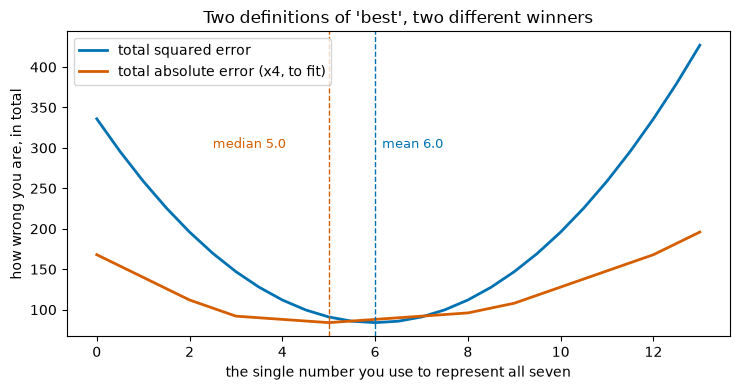

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(guesses, squared_error, color="#0072B2", linewidth=2, label="total squared error")
ax.plot(guesses, absolute_error * 4, color="#D55E00", linewidth=2,
        label="total absolute error (x4, to fit)")
ax.axvline(mean, color="#0072B2", linestyle="--", linewidth=1)
ax.axvline(np.median(late), color="#D55E00", linestyle="--", linewidth=1)
ax.text(mean + 0.15, 300, "mean 6.0", color="#0072B2", fontsize=9)
ax.text(np.median(late) - 2.5, 300, "median 5.0", color="#D55E00", fontsize=9)
ax.set_xlabel("the single number you use to represent all seven")
ax.set_ylabel("how wrong you are, in total")
ax.legend()
ax.set_title("Two definitions of 'best', two different winners")
plt.tight_layout()
plt.show()

### The fork you will meet again

**The mean is the number that minimises total squared error. The median is the number that minimises
total absolute error.** Neither is more correct. They answer different questions, and the question is
chosen by what your errors cost.

- If being wrong by 10 is more than ten times as bad as being wrong by 1 - a delivery van that misses
  a shift, a forecast that empties a warehouse - squaring matches the cost, and the mean is your
  summary.
- If being wrong by 10 is exactly ten times as bad as being wrong by 1, absolute error matches, and
  the median is your summary.

Notice the minimum value of the squared-error curve: **84**, which is the sum of squares you computed
by hand. That is not a coincidence either - the sum of squared deviations *is* the total squared
error at the mean.

You will meet this fork three more times, and it is the same fork every time:

| Where | Squared version | Absolute version |
|---|---|---|
| This chapter | mean | median |
| Model errors (07) | RMSE | MAE |
| Fitting a model (03-08, 05) | least squares | least absolute deviation |
| Robustness | breaks with one bad point | needs half the data corrupted |

## Spread: from squares back to minutes

The sum of squares was 84. To turn it into a summary you divide by something to get an average -
and here the trouble starts.

In [5]:
total_squares = (deviations ** 2).sum()

print("sum of squared deviations : %d" % total_squares)
print("divided by n = 7          : %.4f" % (total_squares / 7))
print("divided by n - 1 = 6      : %.4f" % (total_squares / 6))
print()
print("numpy   np.var(late)          : %.4f" % np.var(late))
print("pandas  pd.Series(late).var() : %.4f" % pd.Series(late).var())

sum of squared deviations : 84
divided by n = 7          : 12.0000
divided by n - 1 = 6      : 14.0000

numpy   np.var(late)          : 12.0000
pandas  pd.Series(late).var() : 14.0000


## Failure lab: the same data, two variances, no warning

`np.var` returns **12.0**. `pd.Series(...).var()` returns **14.0**. Same seven numbers, same machine,
same session. Neither raises anything.

The difference is a parameter called `ddof` - delta degrees of freedom - which sets what you divide
by: `n - ddof`. **numpy defaults to `ddof=0`, pandas defaults to `ddof=1`.** On seven values that is
a 16.7% difference in the variance and 8% in the standard deviation. It gets smaller as `n` grows and
it never disappears.

This bites in a specific, quiet way: you standardise features with one library and compute a summary
with the other, and the numbers no longer agree. Nothing errors.

### Which one is right?

They answer different questions.

- **`ddof=0`** treats your seven numbers as **the whole population**. The variance of exactly these
  seven mornings is 12.
- **`ddof=1`** treats them as **a sample** from a larger population - all the mornings, of which you
  observed seven - and estimates that population's variance as 14.

Almost always you are in the second case: the data is a sample and you care about the process behind
it. So `ddof=1` is usually what you want, which makes numpy's default the surprising one.

### Why dividing by `n` is too small

The claim is that dividing by `n` systematically underestimates. Rather than derive it, measure it:
draw many samples from a population whose variance is known to be exactly 1, and see what each
formula gives on average.

In [6]:
rng = np.random.default_rng(0)
rows = []
for n in [5, 10, 30]:
    samples = rng.normal(0, 1, (200_000, n))          # true variance is exactly 1
    dev = samples - samples.mean(axis=1, keepdims=True)
    rows.append({
        "sample size n": n,
        "average of /n": round(float((dev ** 2).sum(axis=1).mean() / n), 4),
        "average of /(n-1)": round(float((dev ** 2).sum(axis=1).mean() / (n - 1)), 4),
        "(n-1)/n": round((n - 1) / n, 4),
    })
print(pd.DataFrame(rows).to_string(index=False))
print("\nthe true variance of the population is 1.0000")

 sample size n  average of /n  average of /(n-1)  (n-1)/n
             5         0.8017             1.0022   0.8000
            10         0.8985             0.9984   0.9000
            30         0.9654             0.9987   0.9667

the true variance of the population is 1.0000


### Diagnosis

Dividing by `n` gives **0.8017** on average when the truth is 1, at a sample size of 5 - and
`(n-1)/n` is exactly **0.8000**. The formula is not noisy, it is **biased by a known factor**, and
dividing by `n - 1` corrects it exactly: 1.0022, 0.9984, 0.9987 across the three sizes.

The reason, in one sentence with no algebra: you measured the deviations from *your sample's* mean
rather than from the true mean, and your sample's mean sits closer to your own data than the true
mean does - so your squared deviations come out too small, by exactly the amount that `n - 1` fixes.

At n = 30 the correction is 3%, and at n = 5 it is 20%. **Small samples are where this matters**,
which is also where people are most likely to write `np.var` without thinking.

## Standard deviation: getting the units back

The variance of the bus data is 14 - but **14 what?** The deviations were in minutes, and squaring
them made the units minutes-squared. A spread of "14 square minutes" is not a sentence anyone can
act on.

The standard deviation is the square root of the variance, which puts the units back to minutes.

In [7]:
print("variance (ddof=1)          : %.4f  square minutes" % late.var(ddof=1))
print("standard deviation         : %.4f  minutes" % late.std(ddof=1))
print("mean absolute deviation    : %.4f  minutes" % np.abs(late - mean).mean())
print()
inside = ((late > mean - late.std(ddof=1)) & (late < mean + late.std(ddof=1))).sum()
print("values within one sd of the mean: %d of %d" % (inside, len(late)))

variance (ddof=1)          : 14.0000  square minutes
standard deviation         : 3.7417  minutes
mean absolute deviation    : 3.1429  minutes

values within one sd of the mean: 5 of 7


### What a standard deviation means, and what it does not

**It means:** a typical distance from the mean, in the data's own units. Here, mornings are typically
about 3.7 minutes away from the 6-minute average.

**A fair question:** if you want a typical distance from the mean, why not just average the absolute
distances? That is the mean absolute deviation, it is **3.14 minutes**, it is arguably the more
honest answer to the question, and it needs no squaring or square-rooting.

The honest answer is that the mean absolute deviation is a perfectly good measure of spread, and the
standard deviation wins for reasons that have nothing to do with being more descriptive:

- squares are differentiable everywhere and absolute values are not, which matters enormously the
  moment you want to *optimise* something (03-08);
- variances of independent quantities add, and mean absolute deviations do not;
- the normal distribution is written in terms of it, so every result about normals is expressed in
  standard deviations.

**What it does not mean.** "About two thirds of the data lies within one standard deviation" is a
fact about the *normal distribution*, not about data in general. Here it is 5 of 7, which is 71%, and
on the festival data in 02-05 it was nowhere near. Whenever you use a rule of thumb about standard
deviations, you have quietly assumed a shape.

## Failure lab 2: a quartile is a convention

The median is unambiguous with an odd count: sort, take the middle. Quartiles are not, because
"one quarter of the way through seven values" lands between two of them, and there is no single
right way to resolve that.

numpy implements thirteen definitions. Here they all are, on our seven numbers.

In [8]:
methods = ["inverted_cdf", "averaged_inverted_cdf", "closest_observation",
           "interpolated_inverted_cdf", "hazen", "weibull", "linear",
           "median_unbiased", "normal_unbiased", "lower", "higher", "midpoint", "nearest"]

rows = []
for method in methods:
    q1 = float(np.quantile(late, 0.25, method=method))
    q3 = float(np.quantile(late, 0.75, method=method))
    rows.append({"method": method, "Q1": round(q1, 3), "Q3": round(q3, 3),
                 "IQR": round(q3 - q1, 3)})

quartiles = pd.DataFrame(rows)
print(quartiles.to_string(index=False))
print()
print("distinct IQR values:", sorted(float(v) for v in quartiles["IQR"].unique()))
print("numpy and pandas both default to 'linear'.")

                   method   Q1    Q3   IQR
             inverted_cdf 3.00 9.000 6.000
    averaged_inverted_cdf 3.00 9.000 6.000
      closest_observation 3.00 8.000 5.000
interpolated_inverted_cdf 2.75 8.250 5.500
                    hazen 3.00 8.750 5.750
                  weibull 3.00 9.000 6.000
                   linear 3.00 8.500 5.500
          median_unbiased 3.00 8.833 5.833
          normal_unbiased 3.00 8.812 5.812
                    lower 3.00 8.000 5.000
                   higher 3.00 9.000 6.000
                 midpoint 3.00 8.500 5.500
                  nearest 3.00 8.000 5.000

distinct IQR values: [5.0, 5.5, 5.75, 5.812, 5.833, 6.0]
numpy and pandas both default to 'linear'.


### Diagnosis

The interquartile range of these seven numbers is **anywhere between 5.0 and 6.0** - a 20% spread -
depending on which convention you use. Q3 ranges from 8.0 to 9.0. Every one of those answers is
correct under its own definition, and no library warns you which you got.

**What follows from this:**

- On small samples, do not report a quartile to three decimals. The third decimal is a property of
  the method, not the data.
- If two people's quartiles disagree, check the method before checking the data.
- The effect shrinks as `n` grows - with thousands of rows the methods converge, because there is
  always a data point near the quarter mark.
- It does not go away for the **median** either when `n` is even: some conventions average the two
  middle values, some take the lower. numpy averages.

None of this makes quantiles unreliable. It makes them **definitions**, and a definition needs to be
stated when the numbers are small enough for it to matter.

## Robustness, measured

02-05 said the median resists outliers and the mean does not. Here is that claim as a number.

Take the seven mornings and let one of them go wrong - a bus so late it must have broken down.
Nothing else changes.

In [9]:
rows = []
for replacement in [12, 20, 50, 200, 1000]:
    corrupted = late.copy()
    corrupted[-1] = replacement
    rows.append({
        "worst morning": replacement,
        "mean": round(float(corrupted.mean()), 2),
        "median": float(np.median(corrupted)),
        "sd": round(float(corrupted.std(ddof=1)), 2),
    })
print(pd.DataFrame(rows).to_string(index=False))

 worst morning   mean  median     sd
            12   6.00     5.0   3.74
            20   7.14     5.0   6.26
            50  11.43     5.0  17.21
           200  32.86     5.0  73.75
          1000 147.14     5.0 376.08


### The breakdown point

One value out of seven moves the mean from **6.00 to 147.14**. The median does not move at all - it
stays at exactly **5.0** for every one of those, including 1000.

The formal version of this is the **breakdown point**: the fraction of the data an adversary must
corrupt before your summary can be made arbitrarily wrong.

| Summary | Breakdown point | Meaning |
|---|---|---|
| Mean | 0 | one value out of any number of values is enough |
| Standard deviation | 0 | same, and worse - it moves faster, since deviations are squared |
| Median | 0.5 | half the data must be corrupted before it can be pushed anywhere |
| Interquartile range | 0.25 | a quarter |
| Trimmed mean (drop 10% each end) | 0.1 | the fraction you trimmed |

**Do not read this as "the median is safer, use the median."** In 02-05 the extreme values were
festival days - real, and the whole point of the analysis. A robust summary would have hidden them.
Robustness is the right property when extremes are *errors* and the wrong property when extremes are
*the finding*. Which they are is not a statistical question, and no summary can decide it for you.

## One more mean: when the rows are not equal

02-01 asked what one row represents. Here is that question in arithmetic form.

Three bus routes report their average lateness. Route A is the busy one.

In [10]:
routes = pd.DataFrame({
    "route": ["A", "B", "C"],
    "buses": [40, 5, 5],
    "mean_late": [3.0, 15.0, 18.0],
})
print(routes.to_string(index=False))
print()
print("average of the three route averages : %.2f minutes" % routes["mean_late"].mean())
print("weighted by how many buses ran      : %.2f minutes"
      % np.average(routes["mean_late"], weights=routes["buses"]))
print()
total_minutes = (routes["mean_late"] * routes["buses"]).sum()
print("check: %.0f total late-minutes / %d buses = %.2f"
      % (total_minutes, routes["buses"].sum(), total_minutes / routes["buses"].sum()))

route  buses  mean_late
    A     40        3.0
    B      5       15.0
    C      5       18.0

average of the three route averages : 12.00 minutes
weighted by how many buses ran      : 5.70 minutes

check: 285 total late-minutes / 50 buses = 5.70


**12.00 minutes against 5.70 minutes** - the unweighted answer is more than twice the weighted one,
from three rows and no errors anywhere.

The unweighted mean answers *"how late is the typical route?"*. The weighted mean answers *"how late
is the typical bus?"*. Fifty buses ran; forty of them were on route A, which is nearly on time.

**The rule:** whenever you average numbers that are themselves averages, you need the counts they
were computed from, and without them the calculation cannot be done correctly. If a table gives you
group means and no group sizes, that is a missing column, not a minor omission - and it is the same
mechanism that reversed the bike comparison in 02-06.

## Common misconceptions

**"The mean is the average and the median is a robust alternative to it."**
Both are averages in the ordinary sense of "one number standing for many". They are the solutions to
two different problems - minimise squared error, minimise absolute error - and neither is a fallback
for the other.

**"Variance and standard deviation are the same thing."**
They carry the same information and different units. Variance is in squared units and cannot be
interpreted directly; standard deviation is in the data's units and can. Variance is what the algebra
uses; standard deviation is what you put in a sentence.

**"`np.var` and `pandas.var` are the same function."**
They differ by default in `ddof` and will hand you 12 and 14 for the same seven numbers.

**"A standard deviation of 3.7 means most values are within 3.7 of the mean."**
Only under an assumed shape. The two-thirds rule is a property of the normal distribution. Check it
against your data instead of assuming it.

**"Quartiles are exact."**
On small samples they are conventions, and thirteen of them disagree by 20% here.

**"The median throws away information, so use the mean when you can."**
The median uses the ordering of every value; it just does not use their magnitudes. That is a
deliberate trade, and it is the right one whenever magnitudes are unreliable.

**"Average the group averages."**
Only when the groups are the same size. Otherwise you need the weights - 12.00 against 5.70 above.

## Exercises

Solutions: `solutions/03_math_foundations/03-01_summaries_solutions.ipynb`.

### Quick understanding

**E1.** In one sentence each, what problem does the mean solve and what problem does the median
solve?

**E2.** Why is variance measured in squared units, and what does the square root fix?

**E3.** Your colleague reports a variance of 12 and you get 14 from the same data. Neither of you has
made an arithmetic error. What happened, and which of you should change?

### Hand calculation

**E4.** For `[4, 4, 6, 10, 16]`: mean, median, sum of squared deviations, variance both ways, and the
standard deviation with `ddof=1`. Do it on paper, then check with code.

**E5.** Show that the deviations from the mean sum to zero for `[4, 4, 6, 10, 16]`, then explain in
one sentence why this holds for any dataset. Does the same hold for deviations from the median?

**E6.** A shop's mean transaction is 12 EUR and its median is 7 EUR. Sketch the shape of the
distribution and say which number the shop should use to forecast a day's takings from 300
transactions, and why.

### Coding

**E7.** Write `summary(x)` returning a dict with n, mean, median, sd (`ddof=1`), IQR, and the number
of values more than two standard deviations from the mean. Run it on the bus data and on the bus data
with the last value replaced by 200, and describe which entries moved.

**E8.** Reproduce the `ddof` simulation for a **non-normal** population - draw from an exponential
distribution with a known variance instead. Does dividing by `n - 1` still correct the bias exactly?

**E9.** Write `trimmed_mean(x, fraction)` that drops the given fraction from each end before
averaging. Show its breakdown behaviour on the bus data with one corrupted value, for fractions 0,
0.1 and 0.25, and say where it sits between the mean and the median.

### Interpretation

**E10.** A report says "average response time 250 ms, standard deviation 400 ms". What does the
standard deviation being larger than the mean tell you about the shape, and what would you ask for
instead?

**E11.** Two teams have identical mean sales. Team A's standard deviation is 5, team B's is 40. Give
one business reason to prefer A and one to prefer B.

### Debugging

**E12.** An analyst standardises a column as `(x - x.mean()) / np.std(x)` in a script that elsewhere
uses `pandas` for the same operation, and the two versions of the pipeline disagree slightly. Explain
the cause, say how large the effect is for n = 10 and n = 10,000, and give the one-word fix.

### Exam and interview reasoning

**E13.** "When would you report a median rather than a mean?" Answer in four sentences: one case
where the median is right, one where the mean is right, the property that distinguishes them, and one
case where reporting only one of them would be misleading.

### Transfer to a different situation

**E14.** A hospital reports mean length of stay per ward and wants a hospital-wide figure. What extra
column do you need, what goes wrong without it, and which of this chapter's ideas is it?

### Explain it to someone non-technical

**E15.** Explain to a manager why the "average" salary at a company can be a number almost nobody
earns, in under 80 words, without using the words median, distribution or skew.

### Optional challenge

**E16.** The mean minimises total squared error and the median minimises total absolute error. Find
out, by search over a grid, what the number is that minimises the total error when errors are raised
to the power 1.5, and to the power 4. Where do those answers sit relative to the mean and median, and
what does the pattern suggest about the power going to infinity?

In [11]:
# Your workspace. Still in memory: late, mean, deviations, guesses,
# squared_error, absolute_error, quartiles, routes.

## Mastery check

- [ ] Compute mean, median, variance and sd by hand on seven numbers
- [ ] Say what the mean and median each minimise, and name a cost that picks each one
- [ ] Explain `ddof`, name the two library defaults, and say which you usually want
- [ ] Explain in one sentence why dividing by `n` underestimates
- [ ] State the breakdown point of the mean and of the median
- [ ] Weight a mean correctly, and say what goes wrong without weights

## What should now feel instinctive

- Reading "variance" and immediately wondering which divisor
- Seeing a mean and a median far apart and knowing that is information, not a problem
- Asking for the group sizes whenever you are handed group averages
- Refusing to report a quartile to three decimals on twenty rows
- Noticing that "robust" is not a synonym for "better"

## Flashcards

| Front | Back |
|---|---|
| The mean minimises... | total squared error. It is the balance point; deviations sum to zero |
| The median minimises... | total absolute error |
| Variance units | squared. The square root gives the standard deviation, in the data's units |
| `ddof` | divide by `n - ddof`. numpy defaults to 0, pandas to 1 |
| Why `n - 1` | deviations are measured from your own sample mean, so they are too small - by exactly (n-1)/n |
| Breakdown point of the mean | 0 - one value is enough |
| Breakdown point of the median | 0.5 |
| Quartile on a small sample | a convention; numpy has 13, spanning a 20% range on 7 values |
| Averaging group averages | needs the group sizes, or it answers a different question |

## Next

**03-02 · Distributions and sampling: why two samples never agree.** Every number in this chapter was
computed from seven mornings. Tomorrow's seven mornings would give different ones. The next chapter is
about how much different - which turns out to be predictable, and is the foundation of every claim
about uncertainty in the rest of the course.